# GeoBrain Seismic Inversion Example

Three parameterization strategies:
1. Explicit - Direct optimization of model parameters
2. Network - Deep Image Prior approach
3. Latent - Optimization in learned latent space

---

**Seismic inversion** recovers subsurface properties (here, porosity) from
seismic data.  This notebook compares three parameterisation strategies:

| Strategy | Optimised variable | Regularisation |
|----------|--------------------|----------------|
| **Explicit** | Porosity field directly | None (high-dimensional) |
| **Deep Image Prior (DIP)** | CNN decoder weights | Implicit via network architecture |
| **Latent Space** | Low-dimensional latent vector | Strong (decoder expressiveness) |

In [1]:
import sys
sys.path.insert(0, '../..')

import os
import matplotlib
matplotlib.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.titleweight': 'semibold',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.framealpha': 0.9,
    'figure.facecolor': 'white',
    'axes.facecolor': '#fafafa',
    'axes.edgecolor': '#cccccc',
    'axes.linewidth': 0.8,
    'grid.color': '#e0e0e0',
    'grid.linewidth': 0.5,
    'lines.linewidth': 1.5,
    'image.cmap': 'viridis',
})

FIGS_DIR = os.path.join('..', 'figs')
os.makedirs(FIGS_DIR, exist_ok=True)

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from geobrain.geomodel import Simulator, CoSimConfig
from geobrain.physics.wave import RickerWavelet, Shuey, create_conv_matrix
from geobrain.physics.rock import VRH, Gassmann, SoftSand, DensityModel, v_from_moduli
from geobrain.optim import Inverter, bound_constraint
from geobrain.data.transforms import sigmoid_transform
from geobrain.vis import plot_field, plot_comparison

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 2025
torch.manual_seed(SEED)
print(f"Using device: {DEVICE}")

Using device: cpu


## Configuration

64 × 64 × 128 grid with three-angle pre-stack seismic (12°, 24°, 36°).
Rock-physics parameters are consistent with earlier examples.

In [2]:
# Grid
NX, NY, NT = 64, 64, 128

# Physical ranges
PHI_RANGE = (0.05, 0.4)
VSAND_RANGE = (0.2, 0.8)

# Mineral parameters
MINERAL_K = torch.tensor([36.6, 21.0], device=DEVICE)
MINERAL_G = torch.tensor([44.0, 9.0], device=DEVICE)
MINERAL_RHO = torch.tensor([2.65, 2.5], device=DEVICE)
MINERAL_VOL = torch.tensor([0.9, 0.1], device=DEVICE)

# Fluid parameters
FLUID_K = torch.tensor([3.06, 0.10], device=DEVICE)
FLUID_RHO = torch.tensor([1.08, 0.72], device=DEVICE)

# Rock parameters
PRESSURE = 20.0
CRIT_PORO = 0.4
COORD_NUM = 7

# Seismic
ANGLES = [12, 24, 36]
FREQUENCIES = [30, 25, 20]
DT = 0.001

## Rock-Physics Module

The forward operator is wrapped as a `torch.nn.Module` so it integrates
seamlessly into PyTorch's autograd computation graph:

porosity → VRH → Soft Sand → Gassmann → Vp, Vs, ρ

In [3]:
class RockPhysics(nn.Module):
    """Rock physics forward operator."""

    def __init__(self):
        super().__init__()
        self.vrh = VRH()
        self.granular = SoftSand()
        self.fluid = Gassmann()
        self.density = DensityModel()

    def forward(self, poro, vsand):
        # Matrix properties (VRH averaging)
        _, _, K_m = self.vrh(MINERAL_VOL, MINERAL_K)
        _, _, G_m = self.vrh(MINERAL_VOL, MINERAL_G)
        rho_m = (MINERAL_RHO * MINERAL_VOL).sum()

        # Fluid (water saturated)
        k_fl = FLUID_K[0]
        rho_fl = FLUID_RHO[0]

        # Dry rock (Soft Sand model)
        press = torch.ones_like(poro) * PRESSURE
        k_dry, g_dry = self.granular(K_m, G_m, poro, CRIT_PORO, COORD_NUM, press)

        # Saturated rock (Gassmann fluid substitution)
        k_sat, g_sat = self.fluid(k_dry, g_dry, K_m, k_fl, poro)
        rho = self.density(poro, rho_m, rho_fl)

        # Velocities using robust v_from_moduli
        vp, vs = v_from_moduli(k_sat, g_sat, rho)

        return vp, vs, rho

rock_physics = RockPhysics().to(DEVICE)

## Helper Functions

In [4]:
def generate_wavelets(freqs, dt, n_samples):
    """Generate convolution matrices."""
    ricker = RickerWavelet()
    matrices = []
    for f in freqs:
        w, _ = ricker(f0=float(f), dt=float(dt), device=str(DEVICE))
        W = create_conv_matrix(w, n_samples, mode='same').T
        matrices.append(W)
    return matrices

## Generate Synthetic Data

1. **True model**: co-simulated porosity and sand volume (FFT-MA, seed 2025)
2. **Observed seismic**: rock physics → Shuey AVO → wavelet convolution
3. **Initial model**: same workflow with a different seed (1234) — the
   inversion starting point

In [5]:
print("Generating true model...")

corr = torch.tensor([[1.0, 0.7], [0.7, 1.0]])
config = CoSimConfig(
    shape=(NX, NY, NT), lh=20.0, lv=5.0, n_variables=2,
    correlation_matrix=corr, field_names=["phi", "vsand"],
    mean=torch.tensor([0.0, 0.0]), std=torch.tensor([1.0, 1.0]),
    seed=SEED, device=str(DEVICE),
)

simulator = Simulator.create('fft_ma')
fields = simulator.simulate(config)

stacked = torch.stack([fields["phi"], fields["vsand"]])
transformed = sigmoid_transform(stacked, [PHI_RANGE, VSAND_RANGE])
phi_true = transformed[0].to(DEVICE)
vsand = transformed[1].to(DEVICE)

print(f"Porosity: range=[{phi_true.min():.3f}, {phi_true.max():.3f}]")
print(f"Vsand: range=[{vsand.min():.3f}, {vsand.max():.3f}]")

Generating true model...
Porosity: range=[0.057, 0.394]
Vsand: range=[0.211, 0.791]


In [6]:
print("Computing elastic properties...")

vp, vs, rho = rock_physics(phi_true, vsand)

print(f"Vp: range=[{vp.min():.2f}, {vp.max():.2f}] km/s")
print(f"Vs: range=[{vs.min():.2f}, {vs.max():.2f}] km/s")

print("Generating synthetic seismic...")

wavelets = generate_wavelets(FREQUENCIES, DT, NT - 1)
shuey = Shuey()

refl = shuey(vp[:, :, :-1], vs[:, :, :-1], rho[:, :, :-1],
             vp[:, :, 1:], vs[:, :, 1:], rho[:, :, 1:], theta=ANGLES)

seis = torch.zeros((len(ANGLES), NX, NY, NT - 1), device=DEVICE)
for i in range(len(ANGLES)):
    seis[i] = torch.einsum("ijk,lk->ijl", refl[i], wavelets[i])

print(f"Seismic shape: {seis.shape}")

Computing elastic properties...
Vp: range=[2054.48, 3268.41] km/s
Vs: range=[855.38, 1937.22] km/s
Generating synthetic seismic...
Seismic shape: torch.Size([3, 64, 64, 127])


In [7]:
print("Generating initial model...")

config_init = CoSimConfig(
    shape=(NX, NY, NT), lh=20.0, lv=5.0, n_variables=2,
    correlation_matrix=corr, field_names=["phi", "vsand"],
    mean=torch.tensor([0.0, 0.0]), std=torch.tensor([1.0, 1.0]),
    seed=1234, device=str(DEVICE),
)
fields_init = simulator.simulate(config_init)
stacked_init = torch.stack([fields_init["phi"], fields_init["vsand"]])
transformed_init = sigmoid_transform(stacked_init, [PHI_RANGE, VSAND_RANGE])
phi_init = transformed_init[0].to(DEVICE)

print(f"Initial model ready")

Generating initial model...
Initial model ready


## Forward Model Closure

`create_forward()` captures the fixed sand volume, wavelets, and
rock-physics module in a closure, so the forward function only takes
porosity as input — simplifying the inverter interface.

In [8]:
def create_forward(vsand, wavelets, rock_physics):
    """Create forward model function."""
    def forward_fn(phi):
        vp, vs, rho = rock_physics(phi, vsand)
        shuey = Shuey()
        refl = shuey(vp[:, :, :-1], vs[:, :, :-1], rho[:, :, :-1],
                     vp[:, :, 1:], vs[:, :, 1:], rho[:, :, 1:], theta=ANGLES)
        seis = torch.zeros((len(ANGLES), NX, NY, NT - 1), device=DEVICE)
        for i in range(len(ANGLES)):
            seis[i] = torch.einsum("ijk,lk->ijl", refl[i], wavelets[i])
        return seis
    return forward_fn

forward_fn = create_forward(vsand, wavelets, rock_physics)

## Method 1 — Explicit Parameterisation

Directly optimise the porosity field with bound constraints
$\phi \in [0.05, 0.4]$.

- No information loss — full-resolution recovery possible
- High-dimensional; may overfit noise without explicit regularisation

In [9]:
print("Running Explicit Inversion...")

inverter_explicit = Inverter.create(
    initial_model=phi_init.clone(),
    forward_fn=forward_fn,
    constraints=bound_constraint(*PHI_RANGE),
)

result_explicit = inverter_explicit.run(
    observed_data=seis,
    max_epochs=300,
    lr=5e-3,
    verbose=True,
    print_every=50,
)

print(f"\n{result_explicit.summary()}")


Inversion Result
Final loss: 5.773455e-06
Best loss: 5.773455e-06 (epoch 299)
Improvement: 99.9%
Epochs: 300
Time: 6.87s
Converged: False


## Method 2 — Deep Image Prior (DIP)

A randomly initialised convolutional decoder takes a **fixed** noise input
`z_fixed` and outputs the porosity field.  Only the network weights are
optimised.

The convolutional architecture acts as an *implicit* regulariser — it
naturally favours smooth, structured outputs over random noise patterns.

In [10]:
class FCNDecoder(nn.Module):
    """Decoder for DIP."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv3d(8, 32, 3, 1, 1), nn.Upsample(scale_factor=2), nn.ReLU(),
            nn.Conv3d(32, 32, 3, 1, 1), nn.Upsample(scale_factor=2), nn.ReLU(),
            nn.Conv3d(32, 16, 3, 1, 1), nn.Upsample(scale_factor=2), nn.ReLU(),
            nn.Conv3d(16, 1, 3, 1, 1), nn.Sigmoid(),
        )

    def forward(self, z):
        return self.net(z)

latent_shape = (NX // 8, NY // 8, NT // 8)
decoder = FCNDecoder().to(DEVICE)
z_fixed = torch.randn(1, 8, *latent_shape, device=DEVICE)

In [11]:
print("Running Deep Image Prior...")

def net_forward(output):
    phi = output[0, 0] * (PHI_RANGE[1] - PHI_RANGE[0]) + PHI_RANGE[0]
    return forward_fn(phi)

inverter_network = Inverter.create_network(
    network=decoder,
    fixed_input=z_fixed,
    forward_fn=net_forward,
    regularizer='l2',
)

result_network = inverter_network.run(
    observed_data=seis,
    max_epochs=200,
    lr=1e-3,
    regularization_weight=1e-5,
    verbose=True,
    print_every=50,
)

with torch.no_grad():
    phi_network = decoder(z_fixed)[0, 0] * (PHI_RANGE[1] - PHI_RANGE[0]) + PHI_RANGE[0]

print(f"\n{result_network.summary()}")


Inversion Result
Final loss: 7.278127e-05
Best loss: 7.017251e-05 (epoch 193)
Improvement: 98.6%
Epochs: 200
Time: 90.26s
Converged: False


## Method 3 — Latent-Space Optimisation

Freeze the (pre-trained) decoder weights and optimise only the latent
vector `z`.

- Very low-dimensional search space → strong regularisation
- Recovery is limited by the decoder's expressiveness

In [12]:
print("Running Latent Space Optimization...")

z_init = torch.randn(1, 8, *latent_shape, device=DEVICE)

def latent_forward(output):
    phi = output[0, 0] * (PHI_RANGE[1] - PHI_RANGE[0]) + PHI_RANGE[0]
    return forward_fn(phi)

inverter_latent = Inverter.create_latent(
    decoder=decoder,
    initial_latent=z_init,
    forward_fn=latent_forward,
    regularizer='l2',
)

result_latent = inverter_latent.run(
    observed_data=seis,
    max_epochs=100,
    lr=0.1,
    regularization_weight=1e-3,
    verbose=True,
    print_every=20,
)

with torch.no_grad():
    z_opt = inverter_latent.parameterization.latent
    phi_latent = decoder(z_opt)[0, 0] * (PHI_RANGE[1] - PHI_RANGE[0]) + PHI_RANGE[0]

print(f"\n{result_latent.summary()}")


Inversion Result
Final loss: 2.921217e-04
Best loss: 2.921217e-04 (epoch 99)
Improvement: 96.9%
Epochs: 100
Time: 34.65s
Converged: False


## Comparison

Three panels summarise the results:

1. **Model slices** (depth = NT/2): True vs. Explicit vs. DIP vs. Latent
2. **Error maps**: absolute error and RMSE for each method
3. **Convergence**: loss vs. epoch (log scale)

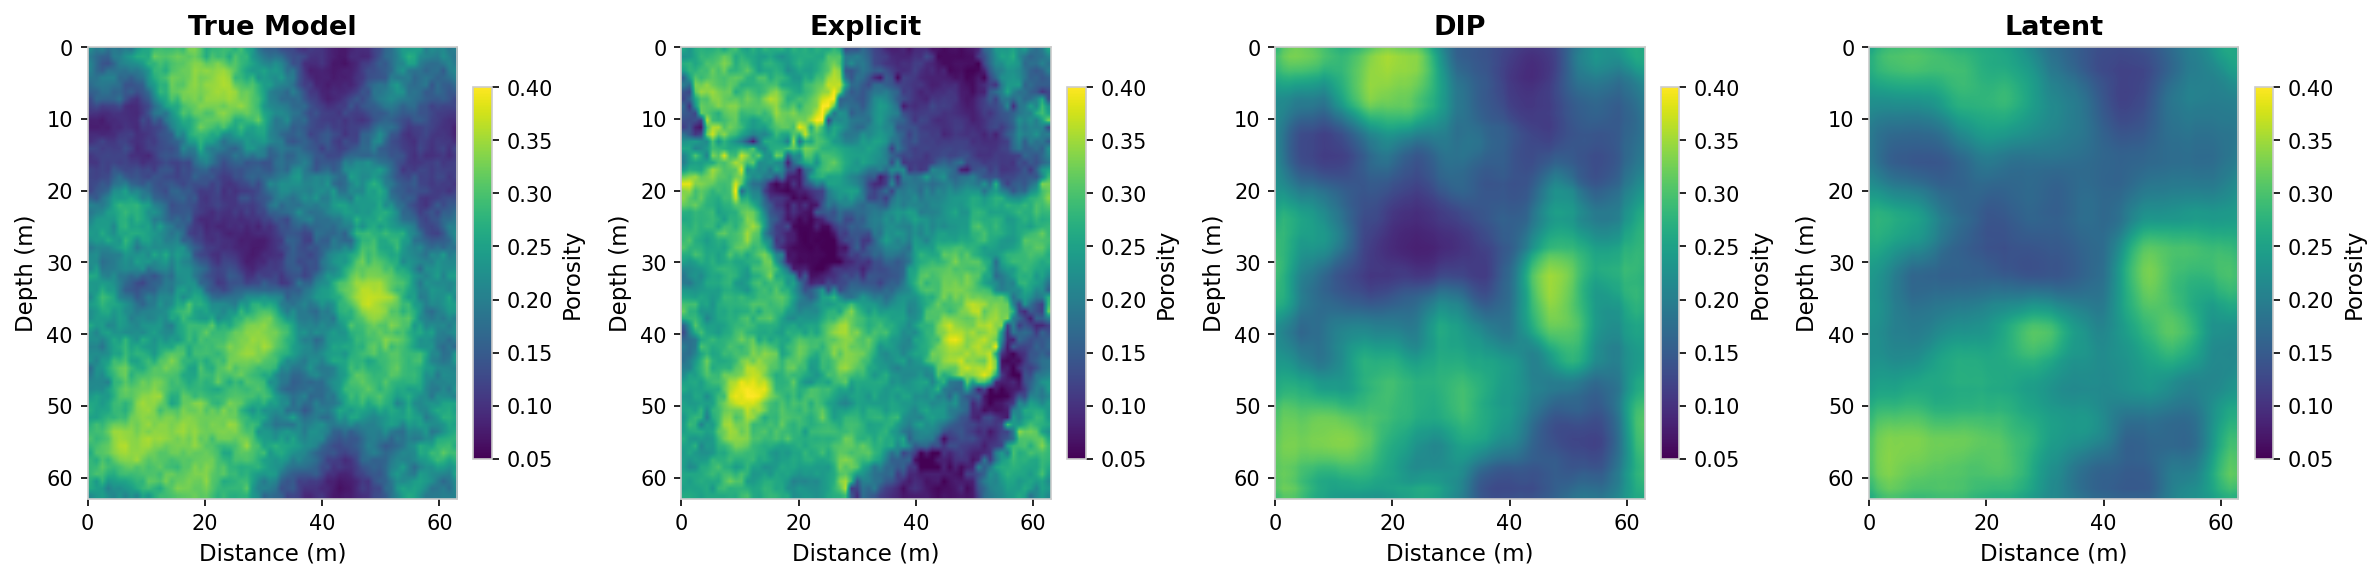

In [13]:
idx = NT // 2
vmin, vmax = PHI_RANGE

# Model comparison
fig, axes = plot_comparison(
    [
        phi_true[:, :, idx].cpu(),
        result_explicit.model[:, :, idx].cpu().detach(),
        phi_network[:, :, idx].cpu().detach(),
        phi_latent[:, :, idx].cpu().detach(),
    ],
    titles=['True Model', 'Explicit', 'DIP', 'Latent'],
    cmap='viridis',
    label='Porosity',
    figsize=(16, 4),
    vmin=vmin, vmax=vmax,
)
plt.savefig(os.path.join(FIGS_DIR, '12_porosity_comparison.png'))
plt.show()

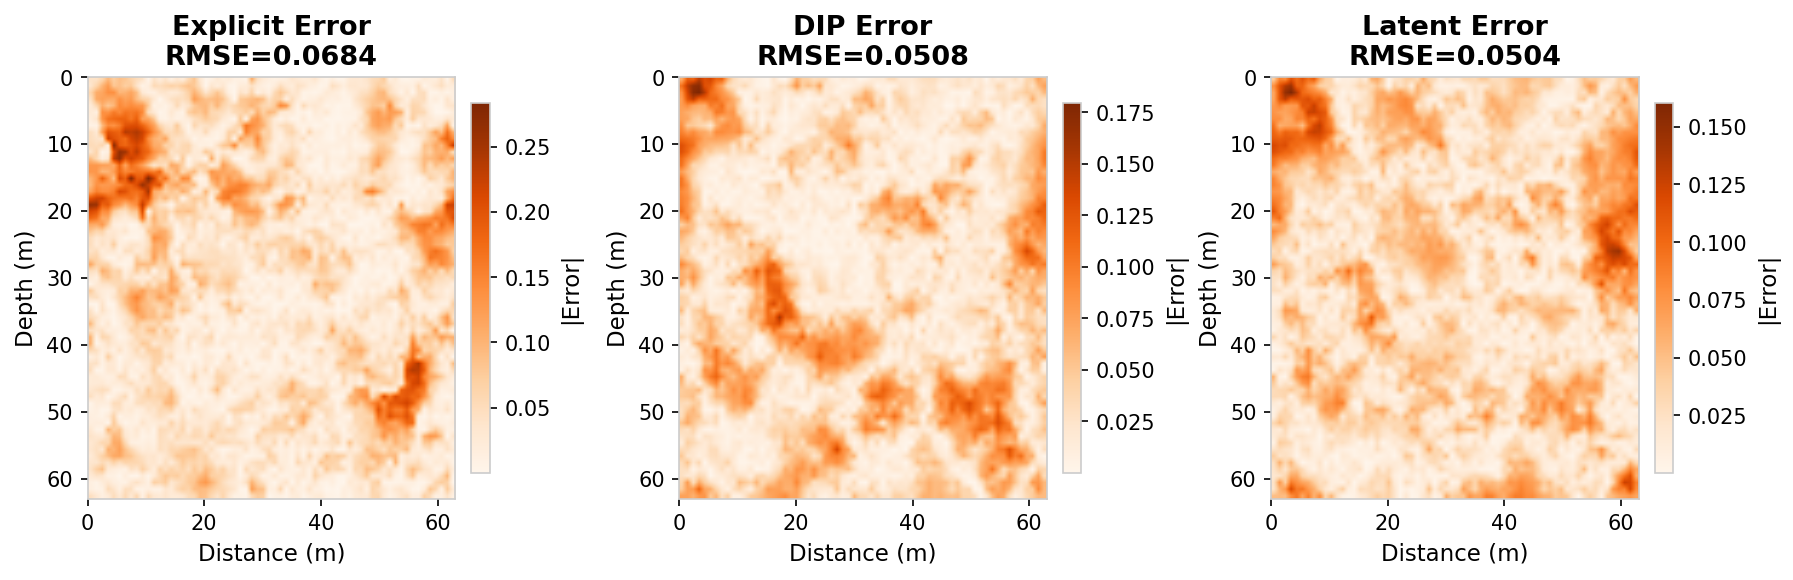

In [14]:
# Error maps
models = [
    ('Explicit', result_explicit.model),
    ('DIP', phi_network),
    ('Latent', phi_latent)
]
err_fields = []
err_titles = []
for name, pred in models:
    err = torch.abs(pred - phi_true)[:, :, idx].cpu().detach()
    rmse = torch.sqrt(torch.mean((pred - phi_true) ** 2)).item()
    err_fields.append(err)
    err_titles.append(f'{name} Error\nRMSE={rmse:.4f}')

fig, axes = plot_comparison(
    err_fields, titles=err_titles,
    cmap='Oranges', share_clim=False,
    label='|Error|', figsize=(12, 4),
)
plt.savefig(os.path.join(FIGS_DIR, '12_error_maps.png'))
plt.show()

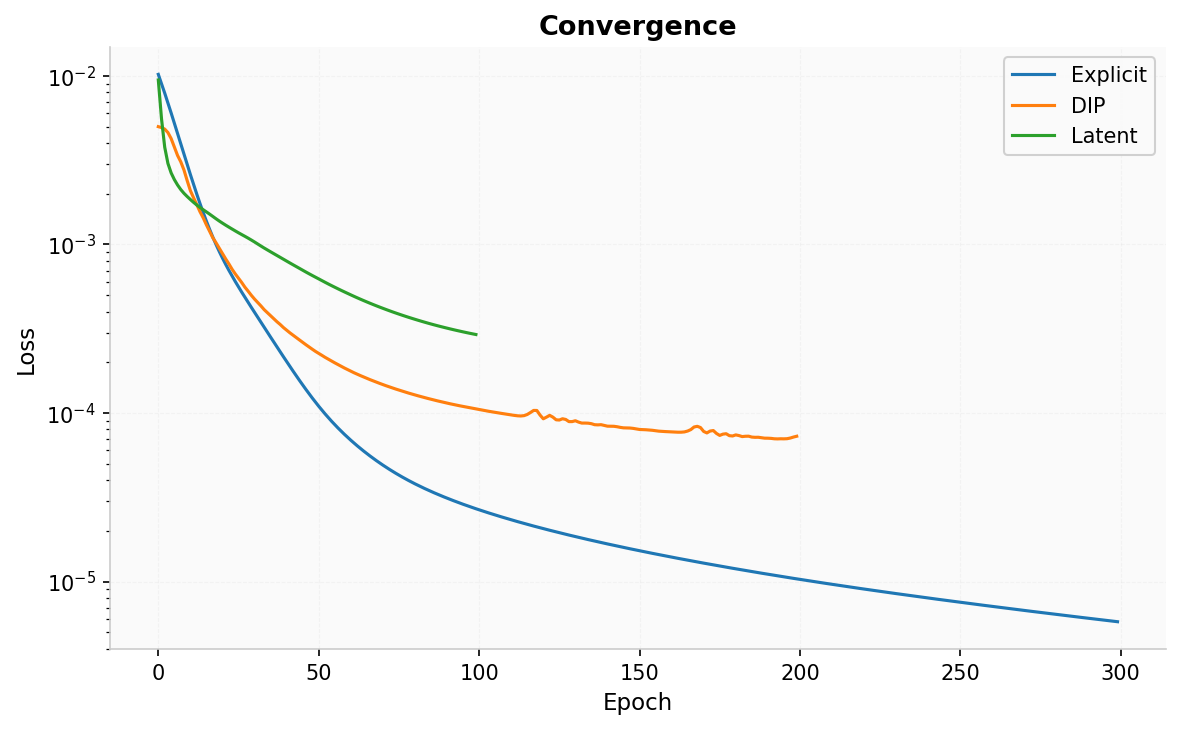

In [15]:
# Convergence
fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(result_explicit.loss_history, color='#1f77b4', label='Explicit')
ax.semilogy(result_network.loss_history, color='#ff7f0e', label='DIP')
ax.semilogy(result_latent.loss_history, color='#2ca02c', label='Latent')
ax.legend()
ax.set_title('Convergence')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.grid(True, alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, '12_convergence.png'))
plt.show()